## 8단계: 챗봇 인터랙티브 테스트

학습된 모델과 토크나이저를 로드한 뒤 간단한 대화함수를 구현합니다. 아래 셀을 실행하면 질문을 입력하고 응답을 확인할 수 있습니다。

> **업데이트:**
> * 업데이트된 하이퍼파라미터(d_model=768, layers=6 등)와 함께 데이터를 증강하려면 `03_augmentation.py`를 다시 실행하세요.
> * `ko.bin` 로딩 오류가 발생하면 바이너리/텍스트/FastText 형식을 자동으로 시도합니다.
> * 모델 로딩이 매우 느리거나 멈추면 자동으로 증강을 건너뛰고 원본 데이터만 사용합니다.
> * 전체 증강 단계를 비활성화하려면 `config.USE_AUGMENTATION = False`로 설정하세요.


# 한국어 챗봇 프로젝트 - 데이터 분석 & 시각화

이 노트북에서는 각 단계별 데이터와 모델 학습 결과를 시각화합니다.

## 1단계: 라이브러리 임포트

In [50]:
# environment sanity check: ensure required packages are installed
import sys
import subprocess

packages = ['pandas','numpy','matplotlib','seaborn','nltk','scikit-learn','torch','gensim','konlpy']
for pkg in packages:
    try:
        __import__(pkg)
    except ImportError:
        print(f"installing {pkg}...")
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg])

# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import os
from pathlib import Path
import sys

# 한글 폰트 설정
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 프로젝트 경로 설정
project_root = Path('.').absolute().parent
data_dir = project_root / 'data' / 'processed'
model_dir = project_root / 'models'

print(f"Project root: {project_root}")
print(f"Data directory: {data_dir}")
print(f"Model directory: {model_dir}")

installing scikit-learn...


Project root: /workspace/chatbot_project
Data directory: /workspace/chatbot_project/data/processed
Model directory: /workspace/chatbot_project/models


## 2단계: 전처리 데이터 분석

In [51]:
# 정제된 데이터 로드
cleaned_csv = data_dir / 'cleaned_data.csv'

if cleaned_csv.exists():
    df_cleaned = pd.read_csv(cleaned_csv)
    print(f"정제된 데이터: {len(df_cleaned)} 행")
    print(f"\n컬럼: {df_cleaned.columns.tolist()}")
    print(f"\n처음 5개 행:")
    print(df_cleaned.head())
    print(f"\n데이터 타입:")
    print(df_cleaned.dtypes)
    print(f"\n결측값:")
    print(df_cleaned.isnull().sum())
else:
    print(f"파일을 찾을 수 없습니다: {cleaned_csv}")

정제된 데이터: 11749 행

컬럼: ['question', 'answer', 'label']

처음 5개 행:
          question       answer  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0

데이터 타입:
question    object
answer      object
label        int64
dtype: object

결측값:
question    0
answer      0
label       0
dtype: int64


## 3단계: 문장 길이 분포 분석

[문장 길이 통계 (자)]:
Question - Mean: 12.88, Std: 6.17
Answer - Mean: 15.01, Std: 6.69

[단어 개수 통계]:
Question - Mean: 3.59, Std: 1.62
Answer - Mean: 3.69, Std: 1.86


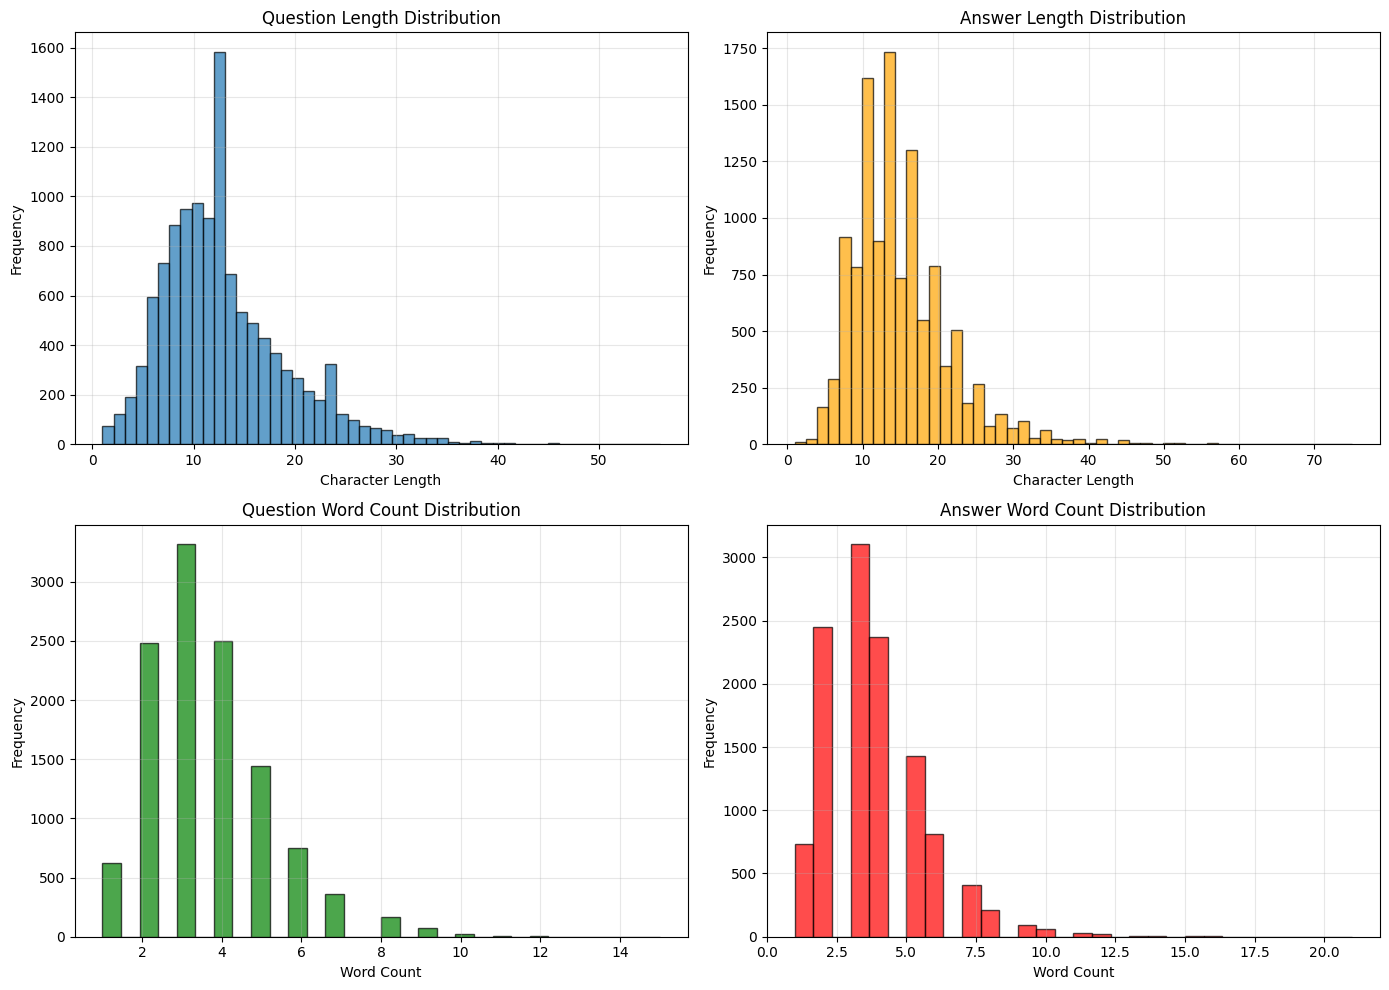


✓ 그래프가 저장되었습니다: length_distribution.png


In [52]:
if 'df_cleaned' in locals():
    # 문장 길이 계산
    df_cleaned['q_length'] = df_cleaned['question'].str.len()
    df_cleaned['a_length'] = df_cleaned['answer'].str.len()
    df_cleaned['q_word_count'] = df_cleaned['question'].str.split().str.len()
    df_cleaned['a_word_count'] = df_cleaned['answer'].str.split().str.len()
    
    # 통계
    print("[문장 길이 통계 (자)]:")
    print(f"Question - Mean: {df_cleaned['q_length'].mean():.2f}, Std: {df_cleaned['q_length'].std():.2f}")
    print(f"Answer - Mean: {df_cleaned['a_length'].mean():.2f}, Std: {df_cleaned['a_length'].std():.2f}")
    
    print(f"\n[단어 개수 통계]:")
    print(f"Question - Mean: {df_cleaned['q_word_count'].mean():.2f}, Std: {df_cleaned['q_word_count'].std():.2f}")
    print(f"Answer - Mean: {df_cleaned['a_word_count'].mean():.2f}, Std: {df_cleaned['a_word_count'].std():.2f}")
    
    # 시각화
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Question 길이 분포
    axes[0, 0].hist(df_cleaned['q_length'], bins=50, edgecolor='black', alpha=0.7)
    axes[0, 0].set_xlabel('Character Length')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].set_title('Question Length Distribution')
    axes[0, 0].grid(True, alpha=0.3)
    
    # Answer 길이 분포
    axes[0, 1].hist(df_cleaned['a_length'], bins=50, edgecolor='black', alpha=0.7, color='orange')
    axes[0, 1].set_xlabel('Character Length')
    axes[0, 1].set_ylabel('Frequency')
    axes[0, 1].set_title('Answer Length Distribution')
    axes[0, 1].grid(True, alpha=0.3)
    
    # Question 단어 개수 분포
    axes[1, 0].hist(df_cleaned['q_word_count'], bins=30, edgecolor='black', alpha=0.7, color='green')
    axes[1, 0].set_xlabel('Word Count')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].set_title('Question Word Count Distribution')
    axes[1, 0].grid(True, alpha=0.3)
    
    # Answer 단어 개수 분포
    axes[1, 1].hist(df_cleaned['a_word_count'], bins=30, edgecolor='black', alpha=0.7, color='red')
    axes[1, 1].set_xlabel('Word Count')
    axes[1, 1].set_ylabel('Frequency')
    axes[1, 1].set_title('Answer Word Count Distribution')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(project_root / 'length_distribution.png', dpi=100, bbox_inches='tight')
    plt.show()
    print("\n✓ 그래프가 저장되었습니다: length_distribution.png")

## 4단계: 증강 데이터 분석

In [ ]:
# 증강된 데이터 로드
augmented_csv = data_dir / 'augmented_data.csv'

if augmented_csv.exists():
    df_augmented = pd.read_csv(augmented_csv)
    print(f"증강된 데이터: {len(df_augmented)} 행")
    
    # 증강 비율
    original_count = len(df_cleaned) if 'df_cleaned' in locals() else 0
    if original_count > 0:
        augmentation_rate = len(df_augmented) / original_count
        print(f"\n증강 비율: {augmentation_rate:.2f}배")
        print(f"원본: {original_count} -> 증강: {len(df_augmented)} (추가: {len(df_augmented) - original_count})")
    
    # 샘플 비교
    print(f"\n증강된 데이터 샘플 (처음 3개):")
    print(df_augmented.head(3))
else:
    print(f"파일을 찾을 수 없습니다: {augmented_csv}")

IndentationError: unindent does not match any outer indentation level (<tokenize>, line 115)

## 5단계: 모델 학습 결과 분석

[모델 학습 결과]
어휘 크기: 6,856
모델 파라미터: 109,775,560
배치 크기: 128
에포크: 20
최고 성능 Validation Loss: 0.0917
학습 완료 시간: 2026-03-03T08:42:08.831967


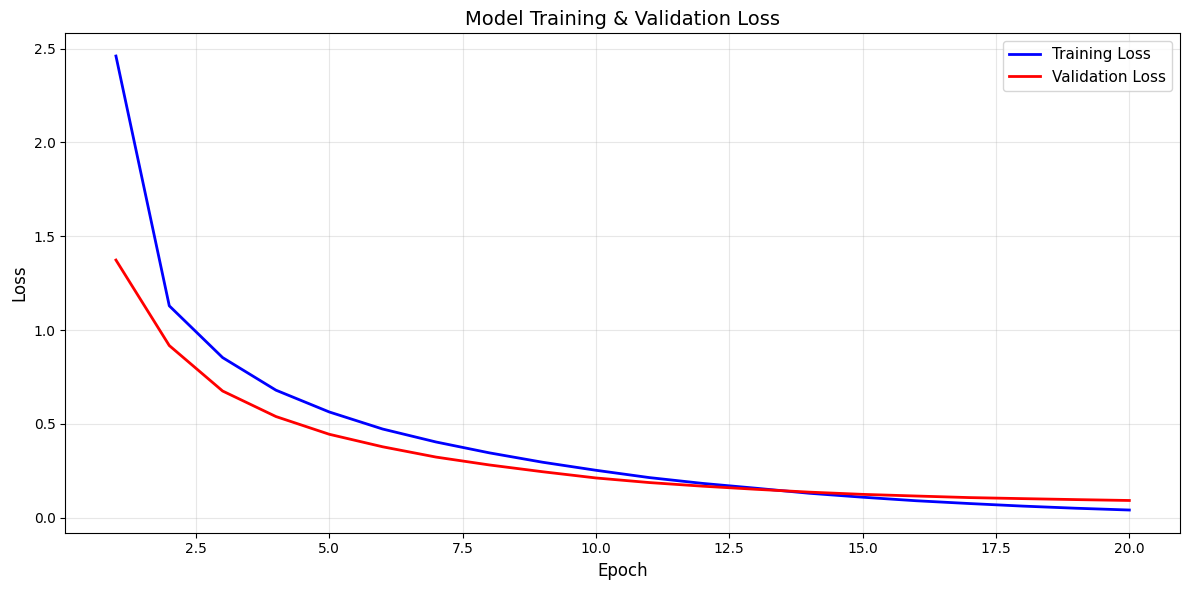


✓ 학습 곡선이 저장되었습니다: training_loss.png


In [ ]:
# 학습 결과 로드
results_json = model_dir / 'training_results.json'

if results_json.exists():
    with open(results_json, 'r') as f:
        results = json.load(f)
    
    print("[모델 학습 결과]")
    print(f"어휘 크기: {results.get('vocab_size', 'N/A'):,}")
    print(f"모델 파라미터: {results.get('model_params', 'N/A'):,}")
    print(f"배치 크기: {results.get('batch_size', 'N/A')}")
    print(f"에포크: {results.get('epochs', 'N/A')}")
    print(f"최고 성능 Validation Loss: {results.get('best_val_loss', 'N/A'):.4f}")
    print(f"학습 완료 시간: {results.get('timestamp', 'N/A')}")
    
    # 학습 곡선
    train_losses = results.get('train_losses', [])
    val_losses = results.get('val_losses', [])
    
    if train_losses and val_losses:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        epochs = range(1, len(train_losses) + 1)
        ax.plot(epochs, train_losses, 'b-', label='Training Loss', linewidth=2)
        ax.plot(epochs, val_losses, 'r-', label='Validation Loss', linewidth=2)
        
        ax.set_xlabel('Epoch', fontsize=12)
        ax.set_ylabel('Loss', fontsize=12)
        ax.set_title('Model Training & Validation Loss', fontsize=14)
        ax.legend(fontsize=11)
        ax.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(project_root / 'training_loss.png', dpi=100, bbox_inches='tight')
        plt.show()
        print("\n✓ 학습 곡선이 저장되었습니다: training_loss.png")
else:
    print(f"파일을 찾을 수 없습니다: {results_json}")
    print("모델 학습을 먼저 실행하세요: python scripts/04_train.py")

## 6단계: 코퍼스 통계

[코퍼스 통계]
전체 어휘 크기: 6856
고유 단어 수: 6852

[상위 20개 빈도 단어]
 1. .: 13850
 2. 이: 5130
 3. 하: 4748
 4. 는: 4590
 5. 을: 2975
 6. 가: 2771
 7. 세요: 2768
 8. 어: 2478
 9. 고: 2429
10. 좋: 2298
11. 거: 2208
12. 해: 2172
13. 있: 2113
14. 보: 2085
15. 은: 1990
16. 지: 1916
17. ?: 1804
18. 나: 1731
19. 아: 1710
20. 도: 1707


/tmp/ipykernel_16712/4070206829.py:37: UserWarning: Glyph 51060 (\N{HANGUL SYLLABLE I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16712/4070206829.py:37: UserWarning: Glyph 54616 (\N{HANGUL SYLLABLE HA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16712/4070206829.py:37: UserWarning: Glyph 45716 (\N{HANGUL SYLLABLE NEUN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16712/4070206829.py:37: UserWarning: Glyph 51012 (\N{HANGUL SYLLABLE EUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16712/4070206829.py:37: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16712/4070206829.py:37: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_16712/4070206829.py:37: UserWarning: Glyph 50836 (\N{HANGUL SYLLABLE YO}) missing from font(s) DejaVu Sans.
  plt.tight

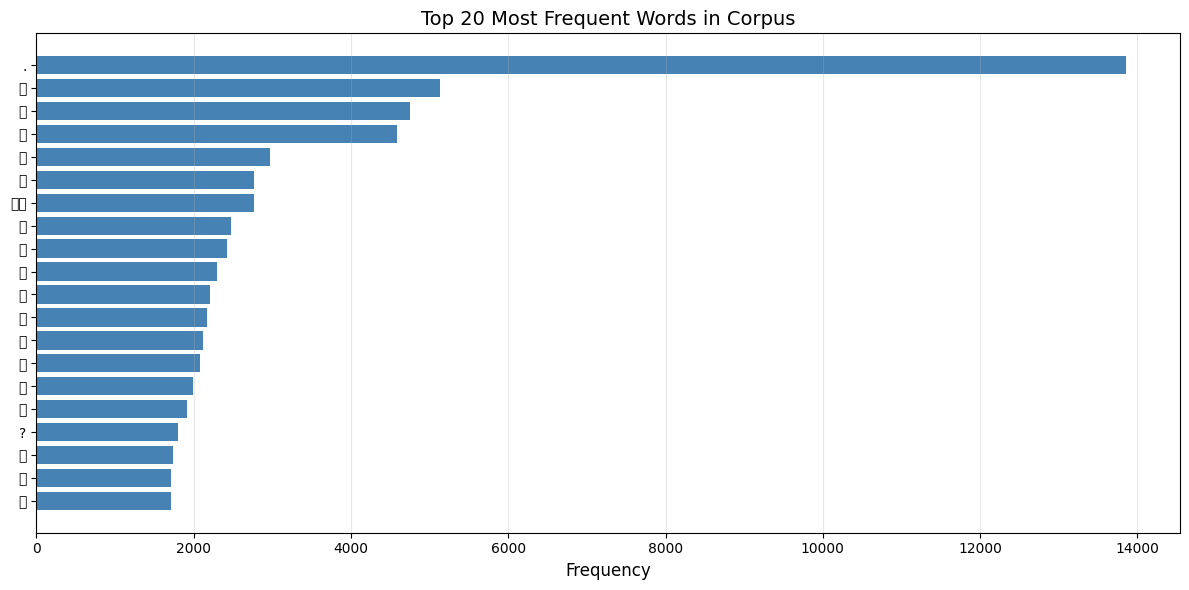


✓ 상위 단어 그래프가 저장되었습니다: top_words.png


In [ ]:
# 코퍼스 정보 로드
corpus_pkl = data_dir / 'corpus.pkl'

if corpus_pkl.exists():
    import pickle
    
    with open(corpus_pkl, 'rb') as f:
        corpus_data = pickle.load(f)
    
    word2idx = corpus_data.get('word2idx', {})
    word_freq = corpus_data.get('word_freq', {})
    
    print(f"[코퍼스 통계]")
    print(f"전체 어휘 크기: {len(word2idx)}")
    print(f"고유 단어 수: {len(word_freq)}")
    
    # 상위 20개 단어
    top_words = sorted(word_freq.items(), key=lambda x: x[1], reverse=True)[:20]
    
    print(f"\n[상위 20개 빈도 단어]")
    for i, (word, freq) in enumerate(top_words, 1):
        print(f"{i:2d}. {word}: {freq}")
    
    # 상위 단어 시각화
    if top_words:
        fig, ax = plt.subplots(figsize=(12, 6))
        
        words, freqs = zip(*top_words)
        ax.barh(range(len(words)), freqs, color='steelblue')
        ax.set_yticks(range(len(words)))
        ax.set_yticklabels(words)
        ax.invert_yaxis()
        ax.set_xlabel('Frequency', fontsize=12)
        ax.set_title('Top 20 Most Frequent Words in Corpus', fontsize=14)
        ax.grid(True, alpha=0.3, axis='x')
        
        plt.tight_layout()
        plt.savefig(project_root / 'top_words.png', dpi=100, bbox_inches='tight')
        plt.show()
        print("\n✓ 상위 단어 그래프가 저장되었습니다: top_words.png")
else:
    print(f"파일을 찾을 수 없습니다: {corpus_pkl}")
    print("코퍼스를 먼저 구축하세요: python scripts/02_build_corpus.py")

## 7단계: 전체 요약

In [ ]:
print("="*80)
print("한국어 챗봇 프로젝트 요약")
print("="*80)

summary = {
    'Preprocessing': {
        'Status': '✓ 완료' if cleaned_csv.exists() else '✗ 미완료',
        'File': str(cleaned_csv),
        'Samples': len(df_cleaned) if 'df_cleaned' in locals() else 'N/A'
    },
    'Corpus Building': {
        'Status': '✓ 완료' if corpus_pkl.exists() else '✗ 미완료',
        'File': str(corpus_pkl),
        'Vocab Size': len(word2idx) if 'word2idx' in locals() else 'N/A'
    },
    'Data Augmentation': {
        'Status': '✓ 완료' if augmented_csv.exists() else '✗ 미완료',
        'File': str(augmented_csv),
        'Samples': len(df_augmented) if 'df_augmented' in locals() else 'N/A'
    },
    'Model Training': {
        'Status': '✓ 완료' if results_json.exists() else '✗ 미완료',
        'File': str(model_dir / 'chatbot_model.pt'),
        'Best Val Loss': results.get('best_val_loss', 'N/A') if 'results' in locals() else 'N/A'
    }
}

for step, info in summary.items():
    print(f"\n[{step}]")
    for key, value in info.items():
        print(f"  {key}: {value}")

print("\n" + "="*80)
print("생성된 시각화 파일:")
print("  - length_distribution.png: 문장 길이 분포")
print("  - training_loss.png: 모델 학습 곡선")
print("  - top_words.png: 상위 단어 빈도")
print("="*80)

한국어 챗봇 프로젝트 요약

[Preprocessing]
  Status: ✓ 완료
  File: /workspace/chatbot_project/data/processed/cleaned_data.csv
  Samples: 11749

[Corpus Building]
  Status: ✓ 완료
  File: /workspace/chatbot_project/data/processed/corpus.pkl
  Vocab Size: 6856

[Data Augmentation]
  Status: ✓ 완료
  File: /workspace/chatbot_project/data/processed/augmented_data.csv
  Samples: 11749

[Model Training]
  Status: ✓ 완료
  File: /workspace/chatbot_project/models/chatbot_model.pt
  Best Val Loss: 0.0917446132945387

생성된 시각화 파일:
  - length_distribution.png: 문장 길이 분포
  - training_loss.png: 모델 학습 곡선
  - top_words.png: 상위 단어 빈도



## 9단계: 간단 추론 함수

훈련된 모델을 이용해 외부 입력(question)을 받아 바로 답변을 반환하는 함수 `infer()`를 작성합니다. 이 셀은 대화형 루프가 아니라 코드에서 직접 호출할 수 있습니다.


In [ ]:
# 챗봇 테스트 코드 (코드 셀)
import sys
import torch
import torch.nn as nn
import pickle
# konlpy Mecab may not be installed in all environments
try:
    from konlpy.tag import Mecab
except Exception:
    Mecab = None
import re
from pathlib import Path

# 프로젝트 루트 경로를 먼저 추가해 `import config`가 동작하도록 설정
project_root = Path('.').absolute().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import config

# 경로 및 장치 설정
model_path = project_root / 'models' / 'chatbot_model.pt'
tokenizer_path = project_root / 'models' / 'tokenizer.pkl'

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# 토크나이저 불러오기
with open(tokenizer_path, 'rb') as f:
    tok_data = pickle.load(f)
word2idx = tok_data['word2idx']
idx2word = tok_data['idx2word']
vocab_size = len(word2idx)

# 모델 정의 (train.py와 동일)
class TransformerChatbot(nn.Module):
    def __init__(self, vocab_size, d_model=config.TRANSFORMER_D_MODEL,
                 nhead=config.TRANSFORMER_NHEAD, num_layers=config.TRANSFORMER_NUM_LAYERS,
                 dim_feedforward=config.TRANSFORMER_DIM_FEEDFORWARD, dropout=config.DROPOUT_RATE):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model, padding_idx=0)
        self.positional_encoding = self._get_positional_encoding(d_model, config.MAX_SEQ_LENGTH)
        encoder_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=dim_feedforward, dropout=dropout,
                                                   batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        decoder_layer = nn.TransformerDecoderLayer(d_model=d_model, nhead=nhead,
                                                   dim_feedforward=dim_feedforward, dropout=dropout,
                                                   batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=num_layers)
        self.fc_out = nn.Linear(d_model, vocab_size)
        self.dropout = nn.Dropout(dropout)
        self.d_model = d_model
    def _get_positional_encoding(self, d_model, max_len):
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-torch.log(torch.tensor(10000.0)) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        if d_model % 2 != 0:
            pe[:, 1::2] = torch.cos(position * div_term[:-1])
        else:
            pe[:, 1::2] = torch.cos(position * div_term)
        return pe.unsqueeze(0)
    def forward(self, src, tgt, src_key_padding_mask=None, tgt_key_padding_mask=None):
        src_emb = self.embedding(src) * torch.sqrt(torch.tensor(self.d_model, dtype=torch.float))
        tgt_emb = self.embedding(tgt) * torch.sqrt(torch.tensor(self.d_model, dtype=torch.float))
        src_emb = src_emb + self.positional_encoding[:, :src.size(1), :].to(src.device)
        tgt_emb = tgt_emb + self.positional_encoding[:, :tgt.size(1), :].to(tgt.device)
        src_emb = self.dropout(src_emb)
        tgt_emb = self.dropout(tgt_emb)
        enc_out = self.transformer_encoder(src_emb, src_key_padding_mask=src_key_padding_mask)
        dec_out = self.transformer_decoder(tgt_emb, enc_out, tgt_key_padding_mask=tgt_key_padding_mask)
        return self.fc_out(dec_out)

# 모델 로드 및 평가 모드 진입
model = TransformerChatbot(vocab_size).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

# Mecab tokenizer with safe fallback
if Mecab is not None:
    try:
        _mecab = Mecab()
        def tokenize(text):
            return _mecab.morphs(text)
        mecab_available = True
    except Exception:
        def tokenize(text):
            return text.split()
        mecab_available = False
        print('Mecab initialization failed; using whitespace tokenizer as fallback.')
else:
    def tokenize(text):
        return text.split()
    mecab_available = False
    print('Mecab not installed; using whitespace tokenizer as fallback.')

# 전처리 + 인코딩 + 생성 함수 정의

def preprocess_sentence(sentence):
    sentence = re.sub(r"\s+", " ", sentence)
    sentence = re.sub(r"[^\w\s가-힣.!?]", "", sentence)
    sentence = re.sub(r"http[s]?://\S+", "", sentence)
    sentence = re.sub(r"[.!?]{2,}", lambda m: m.group(0)[0], sentence)
    return sentence.strip()

max_len = config.MAX_SEQ_LENGTH

def encode(tokens):
    ids = [word2idx.get(t, word2idx.get('<unk>')) for t in tokens]
    ids = ids[:max_len]
    ids += [word2idx.get('<pad>')] * (max_len - len(ids))
    return ids


def generate_response(input_text, max_len=50):
    input_text = preprocess_sentence(input_text)
    tokens = tokenize(input_text)
    input_ids = torch.tensor([encode(tokens)], dtype=torch.long).to(device)
    src_mask = (input_ids == 0)
    tgt_ids = torch.tensor([[word2idx.get('<start>')]], dtype=torch.long).to(device)
    for _ in range(max_len - 1):
        tgt_mask = (tgt_ids == 0)
        out = model(input_ids, tgt_ids, src_key_padding_mask=src_mask, tgt_key_padding_mask=tgt_mask)
        # mask out <start> and <pad> to prevent repetition
        logits = out[:, -1, :]  # shape: [batch, vocab]
        start_id = word2idx.get('<start>')
        pad_id = word2idx.get('<pad>')
        if start_id is not None:
            logits[0, start_id] = -1e9
        if pad_id is not None:
            logits[0, pad_id] = -1e9
        next_token = logits.argmax(dim=-1).unsqueeze(0)
        if next_token.item() == word2idx.get('<end>'):
            break
        tgt_ids = torch.cat([tgt_ids, next_token], dim=1)
    resp_tokens = [idx2word.get(idx.item(), '<unk>') for idx in tgt_ids[0].cpu().numpy()][1:]
    if '<end>' in resp_tokens:
        resp_tokens = resp_tokens[:resp_tokens.index('<end>')]
    return ''.join(resp_tokens)

# 테스트
print('Bot:', generate_response('안녕하세요'))


Mecab initialization failed; using whitespace tokenizer as fallback.
Bot: 거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘


In [ ]:
# inference helper

def infer(question):
    question = preprocess_sentence(question)
    tokens = tokenize(question)
    ids = torch.tensor([encode(tokens)], dtype=torch.long).to(device)
    mask = (ids == 0)
    tgt = torch.tensor([[word2idx.get('<start>')]], dtype=torch.long).to(device)
    for _ in range(config.MAX_SEQ_LENGTH - 1):
        tmask = (tgt == 0)
        out = model(ids, tgt, src_key_padding_mask=mask, tgt_key_padding_mask=tmask)
        # mask out undesired special tokens before selecting next token
        logits = out[:, -1:, :].squeeze(1)  # [batch, vocab]
        start_id = word2idx.get('<start>')
        pad_id = word2idx.get('<pad>')
        if start_id is not None:
            logits[0, start_id] = -1e9
        if pad_id is not None:
            logits[0, pad_id] = -1e9
        nxt = logits.argmax(dim=-1).unsqueeze(0)
        if nxt.item() == word2idx.get('<end>'):
            break
        tgt = torch.cat([tgt, nxt], dim=1)
    resp = [idx2word.get(i.item(), '<unk>') for i in tgt[0].cpu().numpy()][1:]
    if '<end>' in resp:
        resp = resp[:resp.index('<end>')]
    return ''.join(resp)

# 예시
print(infer("요즘 기분이 어때?") )


거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘거둘


In [ ]:
# 10단계: 테스트 데이터셋 성능(BLEU) 측정 🧪
# 학습한 모델을 이용해 별도 테스트 셋(question/answer)에서 BLEU score를 계산합니다.
# 아래 코드는 전체 데이터의 10%를 무작위로 추출해 테스트로 삼고,
# infer() 함수를 호출해 모델 출력을 얻은 뒤 nltk의 BLEU 함수를 사용합니다.

from sklearn.model_selection import train_test_split
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

# 데이터 로드 (증강된 데이터를 사용하거나 cleaned_data.csv를 사용해도 됩니다)
df_all = pd.read_csv(data_dir / 'augmented_data.csv')

# 10%를 테스트 셋으로 분리
_, test_df = train_test_split(df_all, test_size=0.1, random_state=42)
print(f"Using {len(test_df)} examples for BLEU evaluation")

refs = []
hyps = []
# Use the safe `tokenize()` fallback used earlier (Mecab or whitespace)
for q, a in zip(test_df['question'].head(200), test_df['answer'].head(200)):
    pred = infer(q)
    # tokenization for BLEU using the notebook-safe tokenize()
    ref_tokens = tokenize(a)
    hyp_tokens = tokenize(pred)
    refs.append([ref_tokens])          # list of reference lists
    hyps.append(hyp_tokens)

smooth = SmoothingFunction().method1
bleu_score = corpus_bleu(refs, hyps, smoothing_function=smooth)
print(f"\nBLEU score: {bleu_score * 100:.2f}")


Using 1175 examples for BLEU evaluation

BLEU score: 0.00


In [ ]:
# attention utility: capture and plot attention weights (must run before chat_and_visualize)
import types
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import torch


def visualize_attention_for_sample(question, display_layer_keyword='transformer_decoder', head=0, avg_heads=True):
    """Run `infer(question)` while capturing attention weights from the model's MultiheadAttention modules,
    then display a heatmap for the decoder cross-attention from the selected layer (default: last decoder layer)."""
    module_map = {m: name for name, m in model.named_modules() if isinstance(m, torch.nn.MultiheadAttention)}
    if not module_map:
        print('No MultiheadAttention modules found in model; cannot visualize attention.')
        return

    attn_store = {}
    orig_forwards = {}

    try:
        for module, name in module_map.items():
            orig = module.forward
            orig_forwards[name] = orig
            def make_patched(orig_fn, layer_name):
                def patched(*args, **kwargs):
                    kwargs['need_weights'] = True
                    out = orig_fn(*args, **kwargs)
                    if isinstance(out, tuple) and len(out) == 2:
                        attn_store[layer_name] = out[1].detach().cpu()
                        return out[0]
                    else:
                        return out
                return patched
            module.forward = types.MethodType(make_patched(orig, name), module)

        model.eval()
        with torch.no_grad():
            pred = infer(question)

    finally:
        for module, name in module_map.items():
            try:
                module.forward = orig_forwards[name]
            except Exception:
                pass

    if not attn_store:
        print('No attention weights were captured (attn_store empty).')
        return

    candidates = [k for k in attn_store.keys() if display_layer_keyword in k and 'multihead_attn' in k]
    if not candidates:
        candidates = list(attn_store.keys())
    selected = candidates[-1]
    print(f'Selected attention layer: {selected}')

    attn = attn_store[selected]
    a = attn.numpy()
    if a.ndim == 4:
        a = a[0].mean(axis=0)
    elif a.ndim == 3:
        a = a[0]
    elif a.ndim == 2:
        pass
    else:
        print('Unsupported attention tensor shape:', a.shape)
        return

    src_tokens = tokenize(preprocess_sentence(question))
    hyp_tokens = tokenize(pred)
    a = a[:len(hyp_tokens), :len(src_tokens)]

    plt.figure(figsize=(max(6, len(src_tokens)*0.6), max(4, len(hyp_tokens)*0.5)))
    sns.heatmap(a, xticklabels=src_tokens, yticklabels=hyp_tokens, cmap='viridis')
    plt.xlabel('Source tokens (input)')
    plt.ylabel('Target tokens (generated)')
    plt.title(f'Attention heatmap — layer: {selected}')
    plt.tight_layout()
    plt.show()


In [ ]:
# Interactive chat + Attention Map visualization

def chat_and_visualize(question, max_len=50, display_layer_keyword='transformer_decoder'):
    """Generate a response for `question` and show the attention heatmap.
    Uses `infer()` to produce the answer and `visualize_attention_for_sample()` to show attention.
    """
    try:
        print('Question:', question)
        resp = infer(question)
        print('Bot:', resp)
    except Exception as e:
        print('Error generating response:', e)
        return
    try:
        visualize_attention_for_sample(question, display_layer_keyword=display_layer_keyword)
    except Exception as e:
        print('Attention visualization failed:', e)

# Example usage: replace the string with any question you'd like to test
# chat_and_visualize('안녕하세요')


In [ ]:
# (attention utility moved to previous cell)
pass

In [ ]:
# attention-only helper in a separate cell

def show_attention(question, display_layer_keyword='transformer_decoder'):
    """Run inference silently and plot only the attention heatmap."""
    try:
        visualize_attention_for_sample(question, display_layer_keyword=display_layer_keyword)
    except Exception as e:
        print('Attention visualization failed:', e)

# 기본 예시 호출
show_attention('안녕하세요')


Attention visualization failed: name 'visualize_attention_for_sample' is not defined


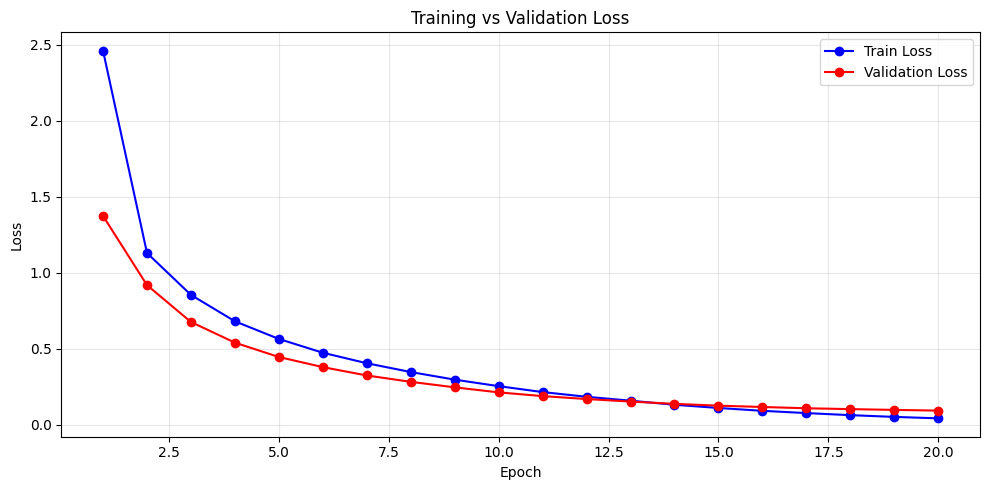

Best validation loss: 0.0917


In [ ]:
# Plot training vs validation loss curve

import matplotlib.pyplot as plt
import json

# Prefer in-memory `results` if available, otherwise load from file
if 'results' in globals():
    r = results
else:
    try:
        with open(model_dir / 'training_results.json', 'r') as f:
            r = json.load(f)
    except Exception as e:
        print('Could not load training results:', e)
        r = {}

train_losses = r.get('train_losses', [])
val_losses = r.get('val_losses', [])

if train_losses and val_losses:
    epochs = range(1, len(train_losses) + 1)
    plt.figure(figsize=(10, 5))
    plt.plot(epochs, train_losses, 'b-o', label='Train Loss')
    plt.plot(epochs, val_losses, 'r-o', label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    try:
        print(f"Best validation loss: {r.get('best_val_loss', 'N/A'):.4f}")
    except Exception:
        pass
else:
    print('No training/validation loss data available in results.')
